# PROJECT 2

### FULL DATASET EXPLORATION - PERSONAL KNOWLEDGE

In [4]:
import pandas as pd
import os
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

files = [
    "Datasets/city_day.csv",
    "Datasets/city_hour.csv",
    "Datasets/station_day.csv",
    "Datasets/station_hour.csv",
    "Datasets/stations.csv"
]

dfs = {}

for file in files:
    print("\n" + "="*60)
    print(f"FILE: {file}")
    print("="*60)

    df = pd.read_csv(file)
    dfs[file] = df

    # Shape
    print("Shape:", df.shape)

    # Columns
    print("\nColumns:")
    print(df.columns.tolist())

    # Data types
    print("\nData Types:")
    print(df.dtypes)

    # Head
    print("\nHead:")
    display(df.head(3))

    # Missing values (top 10 only)
    print("\nTop Missing Values:")
    print(df.isnull().sum().sort_values(ascending=False).head(10))

    # Numerical summary
    print("\nNumerical Summary:")
    display(df.describe())

    # Unique counts (only important columns)
    print("\nUnique Values (sample):")
    for col in df.columns[:10]:
        print(f"{col}: {df[col].nunique()}")

    # =========================
    # TIME CHECK
    # =========================
    time_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    print("\nTime Columns:", time_cols)

    if time_cols:
        try:
            df[time_cols[0]] = pd.to_datetime(df[time_cols[0]], errors='coerce')
            print(f"Converted {time_cols[0]} to datetime")
            print(f"Date Range: {df[time_cols[0]].min()} → {df[time_cols[0]].max()}")
        except:
            print("Datetime conversion failed")

    # Duplicates
    print("\nDuplicates:", df.duplicated().sum())


# =========================
# QUICK COMPARISON 
# =========================

print("\n" + "="*60)
print("DATASET GRANULARITY SUMMARY")
print("="*60)

for file, df in dfs.items():
    time_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    print(f"{file}:")
    print(f"  Rows: {df.shape[0]}")
    print(f"  Time column: {time_cols}")
    print()


FILE: Datasets/city_day.csv
Shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

Head:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN



Top Missing Values:
Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
dtype: int64

Numerical Summary:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000



Unique Values (sample):
City: 26
Date: 2009
PM2.5: 11716
PM10: 12571
NO: 5776
NO2: 7404
NOx: 8156
NH3: 5922
CO: 1779
SO2: 4761

Time Columns: ['Date']
Converted Date to datetime
Date Range: 2015-01-01 00:00:00 → 2020-07-01 00:00:00

Duplicates: 0

FILE: Datasets/city_hour.csv
Shape: (707875, 16)

Columns:
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City              str
Datetime          str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

Head:


...


Unique Values (sample):
StationId: 110
Datetime: 48192
PM2.5: 45086
PM10: 56960
NO: 36985
NO2: 26703
NOx: 40690
NH3: 20523
CO: 7263
SO2: 15385

Time Columns: ['Datetime']
Converted Datetime to datetime
Date Range: 2015-01-01 01:00:00 → 2020-07-01 00:00:00

Duplicates: 0

FILE: Datasets/stations.csv
Shape: (230, 5)

Columns:
['StationId', 'StationName', 'City', 'State', 'Status']

Data Types:
StationId      str
StationName    str
City           str
State          str
Status         str
dtype: object

Head:


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN



Top Missing Values:
Status         97
StationId       0
StationName     0
City            0
State           0
dtype: int64

Numerical Summary:


,StationId,StationName,City,State,Status
count,230,230,230,230,133
unique,230,230,127,21,2
top,AP001,"Secretariat, Amaravati - APPCB",Delhi,Delhi,Active
freq,1,1,38,38,131



Unique Values (sample):
StationId: 230
StationName: 230
City: 127
State: 21
Status: 2

Time Columns: []

Duplicates: 0

DATASET GRANULARITY SUMMARY
Datasets/city_day.csv:
  Rows: 29531
  Time column: ['Date']

Datasets/city_hour.csv:
  Rows: 707875
  Time column: ['Datetime']

Datasets/station_day.csv:
  Rows: 108035
  Time column: ['Date']

Datasets/station_hour.csv:
  Rows: 2589083
  Time column: ['Datetime']

Datasets/stations.csv:
  Rows: 230
  Time column: []



### Which Datasets we are using for this project and why:

* **city_day.csv chosen**: daily granularity → stable trends, suitable for forecasting

* **Less missing data** compared to hourly datasets → cleaner modeling

* **Manageable size (29k rows)** → faster experimentation and iteration

* **City-level aggregation** → reduces noise vs station-level variability

* **Rejected city_hour.csv**: too many missing values + high noise

* **Rejected station_hour.csv**: extremely large + sparse → heavy preprocessing needed

* **Rejected station_day.csv**: adds unnecessary station-level complexity for this project


## 2. DATA ACQUISITION & PREPARATION

#### 2.1 LOAD DATA


In [10]:
df = pd.read_csv("Datasets/city_day.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"])

print(df.shape)
print(df.columns)

(29531, 16)
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='str')


#### 2.2 DATA INSPECTION

In [11]:
# size
print("Shape:", df.shape)

# frequency check (per city)
city = "Delhi"
temp = df[df["City"] == city].copy()

temp = temp.set_index("Date")
print("\nDate range:", temp.index.min(), "→", temp.index.max())

# frequency gaps
print("\nFrequency gaps:")
print(temp.index.to_series().diff().value_counts().head())

# missing values
print("\nMissing values:")
print(temp.isnull().sum().sort_values(ascending=False))

# basic stats
print("\nSummary:")
display(temp.describe())

Shape: (29531, 16)

Date range: 2015-01-01 00:00:00 → 2020-07-01 00:00:00

Frequency gaps:
Date
1 days    2008
Name: count, dtype: int64

Missing values:
Xylene        781
SO2           110
O3             84
PM10           77
AQI            10
AQI_Bucket     10
NH3             9
PM2.5           2
NO              2
NO2             2
City            0
NOx             0
CO              0
Benzene         0
Toluene         0
dtype: int64

Summary:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,2007.000000,1932.000000,2007.000000,2007.000000,2009.000000,2000.000000,2009.000000,1899.000000,1925.00000,2009.000000,2009.000000,1228.000000,1999.000000
mean,117.196153,232.809229,38.985595,50.785182,58.567023,41.997150,1.976053,15.901253,51.32361,3.544480,17.185042,1.438339,259.487744
std,82.912945,121.873025,33.389456,22.696721,37.690350,17.301221,2.560253,7.966770,26.06234,2.431232,15.291597,2.377762,119.537333
min,10.240000,18.590000,3.570000,10.630000,0.000000,6.780000,0.000000,2.340000,6.94000,0.000000,0.000000,0.000000,29.000000
25%,57.095000,137.040000,15.895000,33.895000,31.150000,31.157500,0.910000,10.335000,33.71000,1.870000,6.650000,0.110000,161.500000
50%,94.620000,216.730000,27.200000,47.150000,52.750000,38.040000,1.240000,14.450000,44.44000,2.960000,12.750000,0.650000,257.000000
75%,153.030000,311.667500,50.790000,63.570000,75.360000,48.792500,1.870000,19.700000,60.84000,4.680000,23.200000,1.970000,345.500000
max,685.360000,796.880000,221.030000,162.500000,254.800000,166.700000,30.440000,71.560000,257.73000,20.640000,103.000000,23.300000,716.000000


#### 2.3 FILTER ONE CITY + TARGET SERIES

In [13]:
city = "Delhi"

df["Date"] = pd.to_datetime(df["Date"])

df = df[df["City"] == city].copy()
df = df.sort_values("Date")

df = df.set_index("Date")

series = df["PM2.5"]

print(series.shape)
display(series.head())

(2009,)


Date
2015-01-01    313.22
2015-01-02    186.18
2015-01-03     87.18
2015-01-04    151.84
2015-01-05    146.60
Name: PM2.5, dtype: float64

#### 2.4 HANDLE MISSING VALUES

In [16]:
# interpolate
series = series.interpolate(method="time")

# drop remaining
series = series.dropna()

print("Missing after:", series.isnull().sum())
print("Shape after cleaning:", series.shape)

Missing after: 0
Shape after cleaning: (2009,)


#### 2.5 RESAMPLING / ENSURE DAILY CONTINUITY

In [17]:
# enforce daily frequency
series = series.asfreq("D")

# fill gaps created
series = series.interpolate(method="time")

print("After enforcing frequency:")
print(series.index.to_series().diff().value_counts().head())

After enforcing frequency:
Date
1 days    2008
Name: count, dtype: int64


#### 2.6 TIME FEATURE ENGINEERING 

In [15]:
import numpy as np

df_time = pd.DataFrame(index=series.index)

df_time["value"] = series

# basic time features
df_time["year"] = df_time.index.year
df_time["month"] = df_time.index.month
df_time["day"] = df_time.index.day
df_time["dayofweek"] = df_time.index.dayofweek
df_time["weekofyear"] = df_time.index.isocalendar().week.astype(int)

# cyclic encoding 
df_time["month_sin"] = np.sin(2 * np.pi * df_time["month"]/12)
df_time["month_cos"] = np.cos(2 * np.pi * df_time["month"]/12)

df_time["dow_sin"] = np.sin(2 * np.pi * df_time["dayofweek"]/7)
df_time["dow_cos"] = np.cos(2 * np.pi * df_time["dayofweek"]/7)

display(df_time.head())

,value,year,month,day,dayofweek,weekofyear,month_sin,month_cos,dow_sin,dow_cos
Date,,,,,,,,,,
2015-01-01,313.22,2015,1,1,3,1,0.5,0.866025,0.433884,-0.900969
2015-01-02,186.18,2015,1,2,4,1,0.5,0.866025,-0.433884,-0.900969
2015-01-03,87.18,2015,1,3,5,1,0.5,0.866025,-0.974928,-0.222521
2015-01-04,151.84,2015,1,4,6,1,0.5,0.866025,-0.781831,0.623490
2015-01-05,146.60,2015,1,5,0,2,0.5,0.866025,0.000000,1.000000


#### 2.7 LAG FEATURES (VERY IMPORTANT FOR ML MODELS)

In [18]:
for lag in [1, 2, 3, 7, 14, 30]:
    df_time[f"lag_{lag}"] = df_time["value"].shift(lag)

# rolling stats
df_time["rolling_mean_7"] = df_time["value"].rolling(7).mean()
df_time["rolling_std_7"] = df_time["value"].rolling(7).std()

df_time = df_time.dropna()

print(df_time.shape)
display(df_time.head())

(1966, 18)


,value,year,month,day,dayofweek,weekofyear,month_sin,month_cos,dow_sin,dow_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,,,,,,,
2015-01-31,158.59,2015,1,31,5,5,0.500000,0.866025,-0.974928,-0.222521,178.04,173.13,134.60,164.98,196.46,313.22,153.784286,18.158582
2015-02-01,211.59,2015,2,1,6,5,0.866025,0.500000,-0.781831,0.623490,158.59,178.04,173.13,148.59,201.51,186.18,162.784286,28.065176
2015-02-02,163.64,2015,2,2,0,6,0.866025,0.500000,0.000000,1.000000,211.59,158.59,178.04,129.34,183.35,87.18,167.684286,23.944612
2015-02-03,157.71,2015,2,3,1,6,0.866025,0.500000,0.781831,0.623490,163.64,211.59,158.59,154.20,165.63,151.84,168.185714,23.650113
2015-02-04,137.26,2015,2,4,2,6,0.866025,0.500000,0.974928,-0.222521,157.71,163.64,211.59,134.60,159.54,146.60,168.565714,23.033873


#### 2.8 OUTLIER CHECK (IMPORTANT FOR FORECASTING)

In [20]:
# clip extreme values 
q1 = series.quantile(0.01)
q99 = series.quantile(0.99)

series = series.clip(lower=q1, upper=q99)

display(series.describe())

count    2009.000000
mean      116.198305
std        78.698752
min        21.145360
25%        57.080000
50%        94.490000
75%       152.990000
max       387.818704
Name: PM2.5, dtype: float64

#### 2.9 NORMALIZATION / SCALING

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

series_scaled = scaler.fit_transform(series.values.reshape(-1,1))
series_scaled = pd.Series(series_scaled.flatten(), index=series.index)

display(series_scaled.head())

Date
2015-01-01    2.504115
2015-01-02    0.889457
2015-01-03   -0.368818
2015-01-04    0.453000
2015-01-05    0.386401
Freq: D, dtype: float64

#### 2.10 TRAIN / VALIDATION / TEST SPLIT

In [22]:
n = len(df_time)

train_size = int(n * 0.7)
val_size = int(n * 0.15)

train = df_time[:train_size]
val = df_time[train_size:train_size + val_size]
test = df_time[train_size + val_size:]

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nRanges:")
print("Train:", train.index.min(), "→", train.index.max())
print("Val:", val.index.min(), "→", val.index.max())
print("Test:", test.index.min(), "→", test.index.max())

Train: (1376, 18)
Validation: (294, 18)
Test: (296, 18)

Ranges:
Train: 2015-01-31 00:00:00 → 2018-11-19 00:00:00
Val: 2018-11-20 00:00:00 → 2019-09-09 00:00:00
Test: 2019-09-10 00:00:00 → 2020-07-01 00:00:00


#### 3.1 FULL TIME SERIES VISUALIZATION (TREND + ANOMALIES)

## 3. Exploratory Data Analysis (EDA)

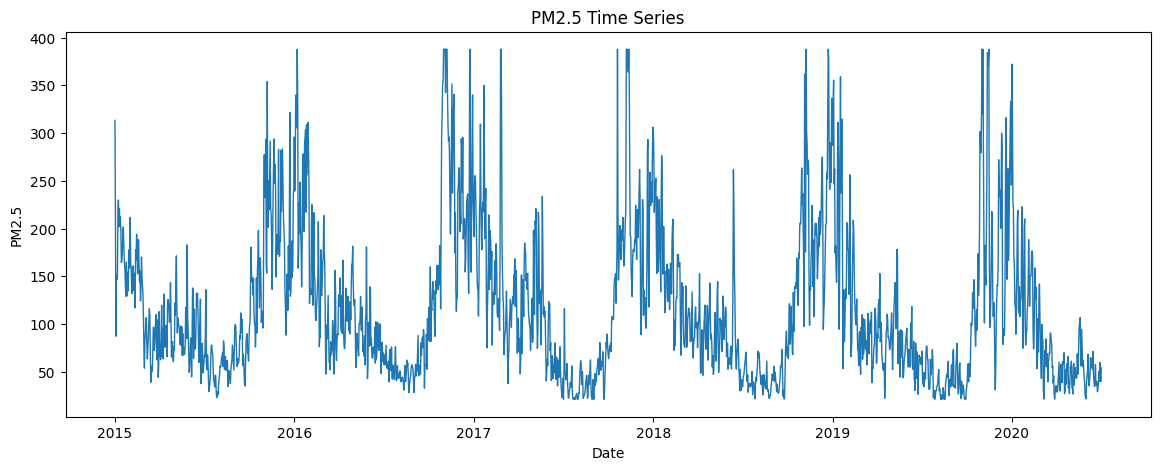

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(series, linewidth=1)
plt.title("PM2.5 Time Series")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.show()

#### 3.2 ROLLING TREND 

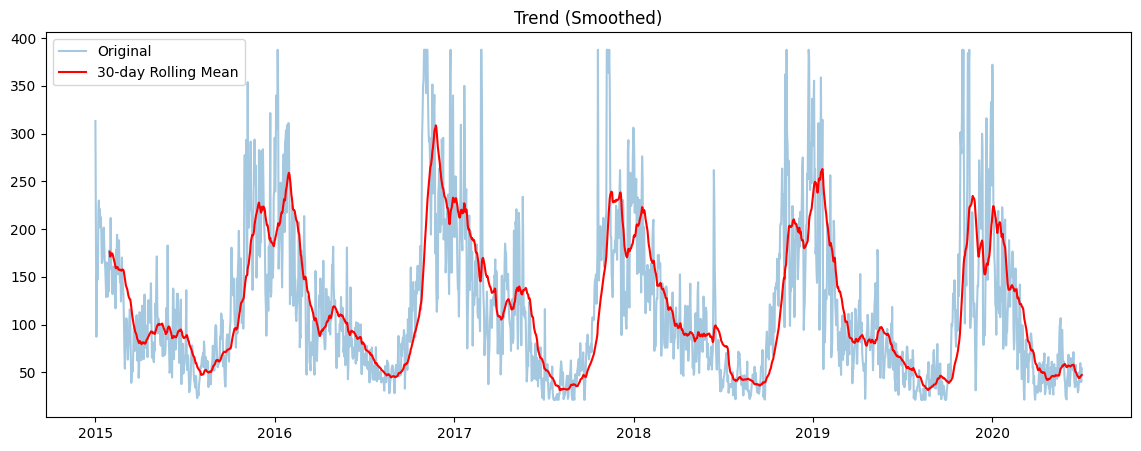

In [24]:
rolling_mean_30 = series.rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(series, alpha=0.4, label="Original")
plt.plot(rolling_mean_30, color="red", label="30-day Rolling Mean")
plt.legend()
plt.title("Trend (Smoothed)")
plt.show()

#### 3.3 SEASONAL DECOMPOSITION

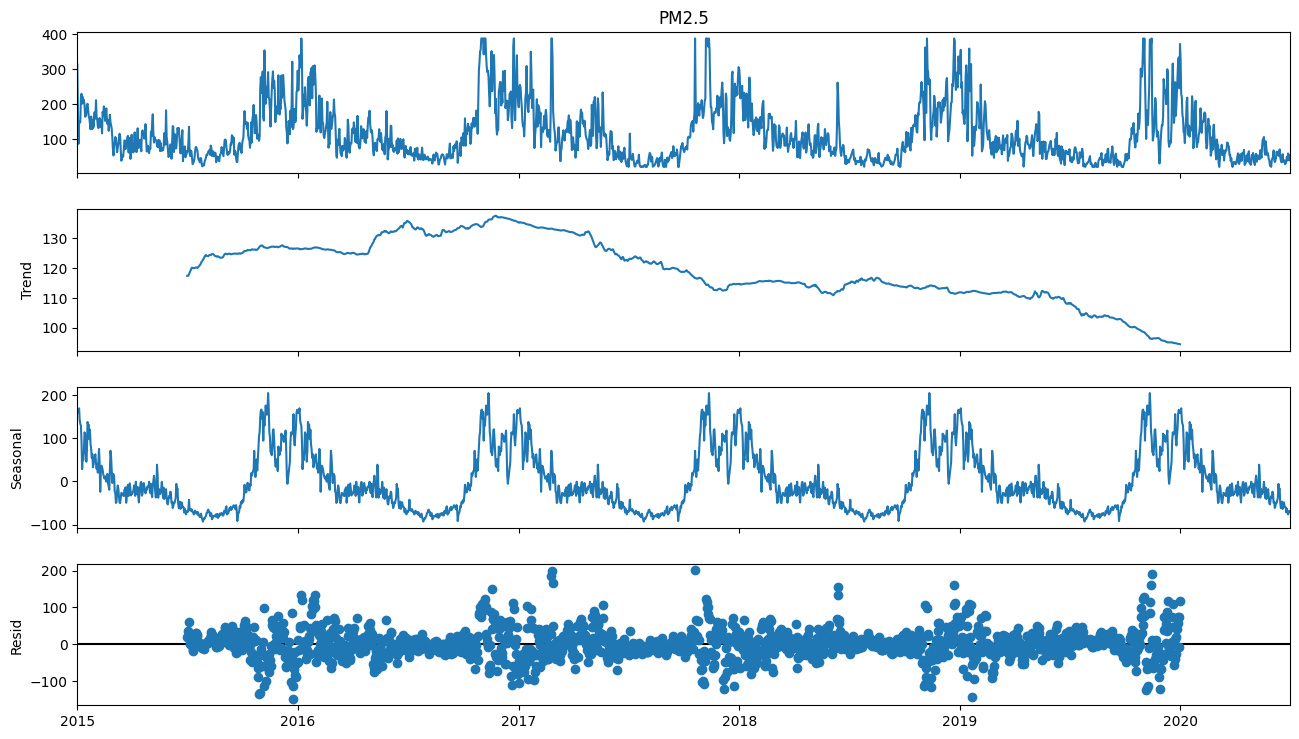

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(series, model='additive', period=365)

fig = decomp.plot()
fig.set_size_inches(14,8)
plt.show()

#### 3.4 MONTHLY SEASONALITY

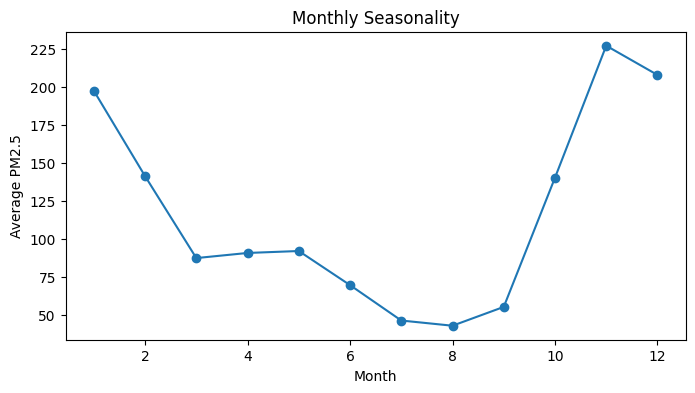

In [29]:
monthly_avg = series.groupby(series.index.month).mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg, marker='o')
plt.title("Monthly Seasonality")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.show()

#### 3.5 DAY-OF-WEEK SEASONALITY

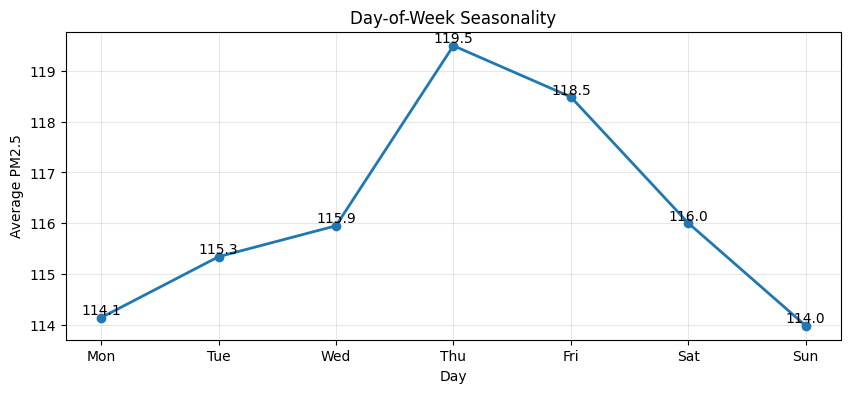

In [30]:
dow_avg = series.groupby(series.index.dayofweek).mean()

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(10,4))
plt.plot(days, dow_avg.values, marker='o', linewidth=2)

for i, v in enumerate(dow_avg.values):
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom')

plt.title("Day-of-Week Seasonality")
plt.xlabel("Day")
plt.ylabel("Average PM2.5")
plt.grid(alpha=0.3)

plt.show()

#### 3.6 DISTRIBUTION + OUTLIERS

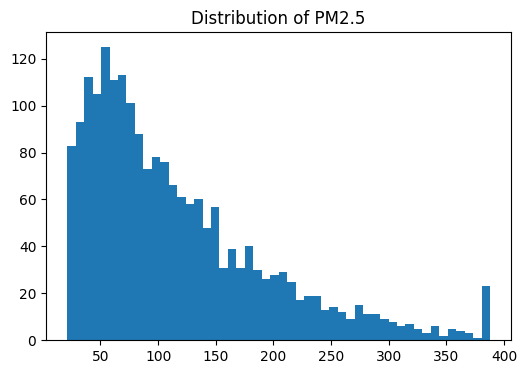

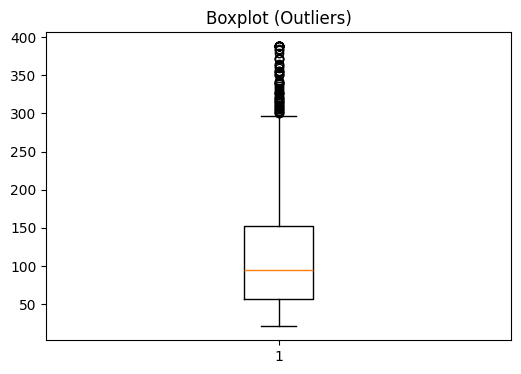

In [31]:
plt.figure(figsize=(6,4))
plt.hist(series, bins=50)
plt.title("Distribution of PM2.5")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(series)
plt.title("Boxplot (Outliers)")
plt.show()

#### 3.7 AUTOCORRELATION (ACF)

<Figure size 1000x400 with 0 Axes>

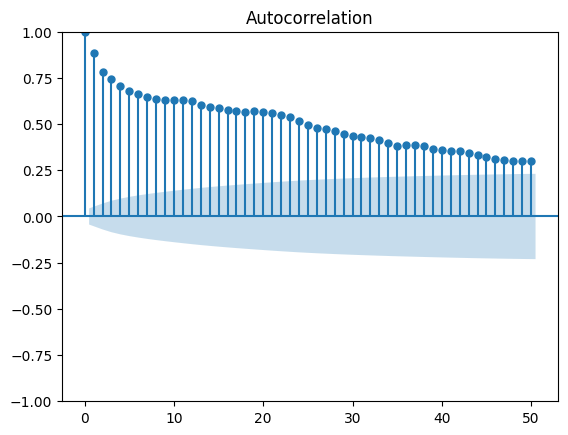

In [32]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(series, lags=50)
plt.show()

#### 3.8 PARTIAL AUTOCORRELATION (PACF)

<Figure size 1000x400 with 0 Axes>

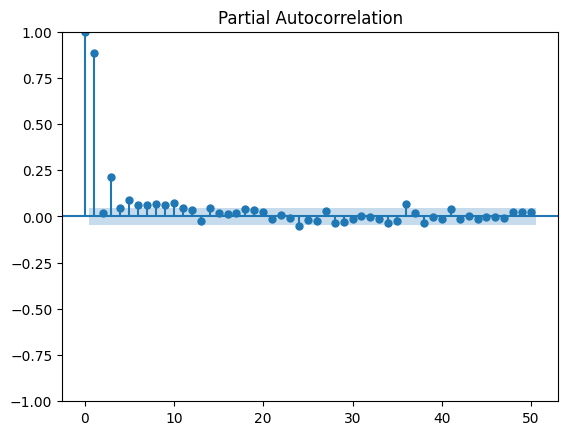

In [33]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(series, lags=50)
plt.show()

#### 3.9 LAG PLOT (DEPENDENCY CHECK)

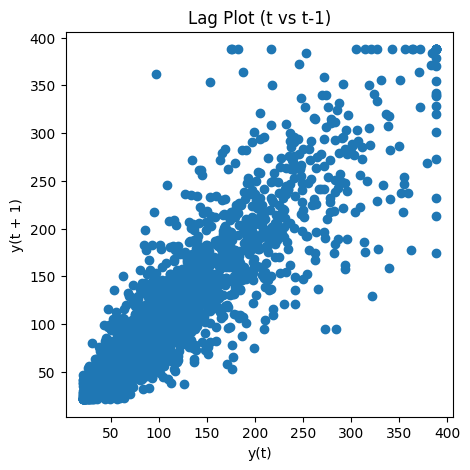

In [34]:
from pandas.plotting import lag_plot

plt.figure(figsize=(5,5))
lag_plot(series)
plt.title("Lag Plot (t vs t-1)")
plt.show()

#### 3.10 CORRELATION WITH OTHER POLLUTANTS (EXTERNAL FACTORS)

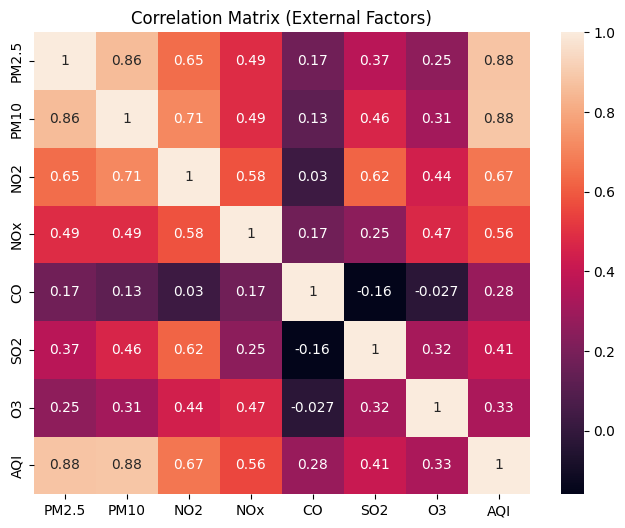

In [36]:
# reload full df for city
df_full = pd.read_csv("Datasets/city_day.csv")
df_full["Date"] = pd.to_datetime(df_full["Date"])
df_full = df_full[df_full["City"] == "Delhi"].set_index("Date")

cols = ["PM2.5","PM10","NO2","NOx","CO","SO2","O3","AQI"]

corr = df_full[cols].corr()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix (External Factors)")
plt.show()

#### 3.11 MULTI-VARIATE TREND (KEY FEATURES)

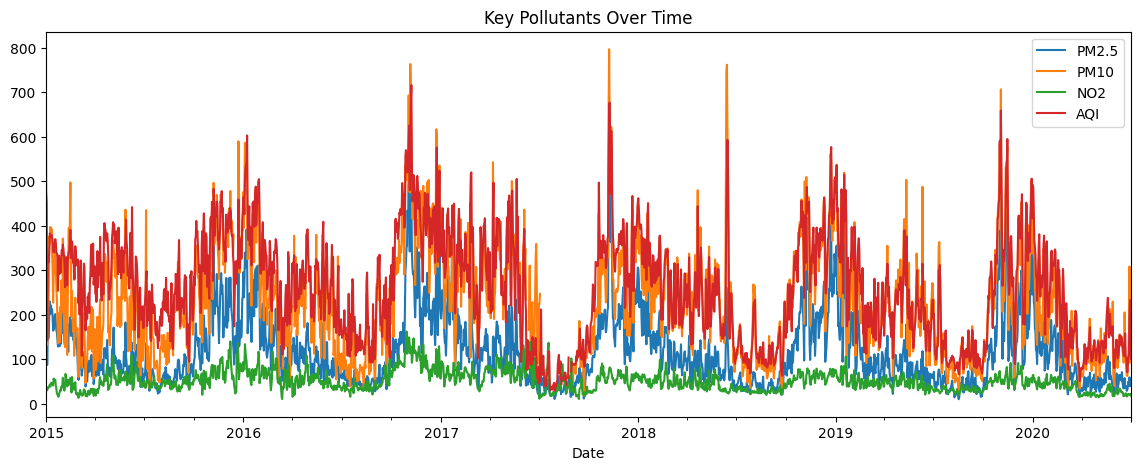

In [37]:
df_full[["PM2.5","PM10","NO2","AQI"]].plot(figsize=(14,5))
plt.title("Key Pollutants Over Time")
plt.show()

# 4. Model Development

#### 4.1 BASELINE 1 - NAIVE FORECAST

In [39]:
# last value forecasting

y_train = train.copy()
y_test = test.copy()

naive_pred = y_test.shift(1)
naive_pred.iloc[0] = y_train.iloc[-1]

naive_pred = naive_pred.dropna()
y_test_naive = y_test.loc[naive_pred.index]

#### 4.2 BASELINE 2 - MOVING AVERAGE

In [40]:
window = 7

ma_pred = y_test.rolling(window=window).mean()

# first prediction using last train values
ma_pred.iloc[:window] = y_train.tail(window).mean()

ma_pred = ma_pred.dropna()
y_test_ma = y_test.loc[ma_pred.index]

#### 4.3 ARIMA MODEL

In [43]:
from statsmodels.tsa.arima.model import ARIMA
y_train_arima = series[:len(train)]
y_test_arima = series[len(train):len(train)+len(test)]

model_arima = ARIMA(y_train_arima, order=(2,1,2))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(steps=len(y_test_arima))
arima_pred.index = y_test_arima.index

#### 4.4 SARIMA MODEL (SEASONAL)

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    y_train_arima,
    order=(1,1,1),
    seasonal_order=(0,1,1,7),
    trend='n'
)

model_sarima_fit = model_sarima.fit(
    disp=False,
    maxiter=200
)

sarima_pred = model_sarima_fit.forecast(steps=len(y_test_arima))
sarima_pred.index = y_test_arima.index

#### 4.5 LSTM MODEL

In [48]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
test_scaled = scaler.transform(y_test.values.reshape(-1,1))

def create_seq(data, window=30):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 30

X_train, y_train_lstm = create_seq(train_scaled, window)
X_test, y_test_lstm = create_seq(test_scaled, window)

X_train = X_train.reshape((X_train.shape[0], window, 1))
X_test = X_test.reshape((X_test.shape[0], window, 1))

model = Sequential([
    LSTM(64, input_shape=(window,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train_lstm, epochs=15, batch_size=32, verbose=1)

# predict
lstm_pred = model.predict(X_test)

# inverse scale
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

# flatten
lstm_pred = lstm_pred.flatten()
y_test_lstm = y_test_lstm.flatten()

# correct index
lstm_index = y_test.index[window:]

min_len = min(len(lstm_pred), len(lstm_index))

lstm_pred = pd.Series(lstm_pred[:min_len], index=lstm_index[:min_len])
y_test_lstm = pd.Series(y_test_lstm[:min_len], index=lstm_index[:min_len])

Epoch 1/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0228
Epoch 2/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0039
Epoch 3/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0021
Epoch 4/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0016
Epoch 5/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0010    
Epoch 6/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.0685e-04
Epoch 7/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8259e-04
Epoch 8/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.5222e-04
Epoch 9/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.0243e-04
Epoch 10/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.3137e-04
Epoch 11/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.7327e-04
Epoch 12/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.6597e-04
Epoch 13/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.2874e-04
Epoch 14/15
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.2796e-04
Epoch 15/15
774/7

#### 4.6 EVALUATION METRICS

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

results = {}

results["Naive"] = evaluate(y_test_naive, naive_pred)
results["MovingAvg"] = evaluate(y_test_ma, ma_pred)
results["ARIMA"] = evaluate(y_test_arima, arima_pred)
results["SARIMA"] = evaluate(y_test_arima, sarima_pred)
results["LSTM"] = evaluate(y_test_lstm, lstm_pred)

for k,v in results.items():
    print(f"{k}: MAE={v[0]:.2f}, RMSE={v[1]:.2f}, MAPE={v[2]:.2f}%")

Naive: MAE=11.84, RMSE=29.67, MAPE=inf%
MovingAvg: MAE=16.32, RMSE=36.37, MAPE=inf%
ARIMA: MAE=65.35, RMSE=95.98, MAPE=46.16%
SARIMA: MAE=73.40, RMSE=103.51, MAPE=46.54%
LSTM: MAE=13.74, RMSE=18.31, MAPE=inf%


#### 4.7 VISUAL COMPARISON

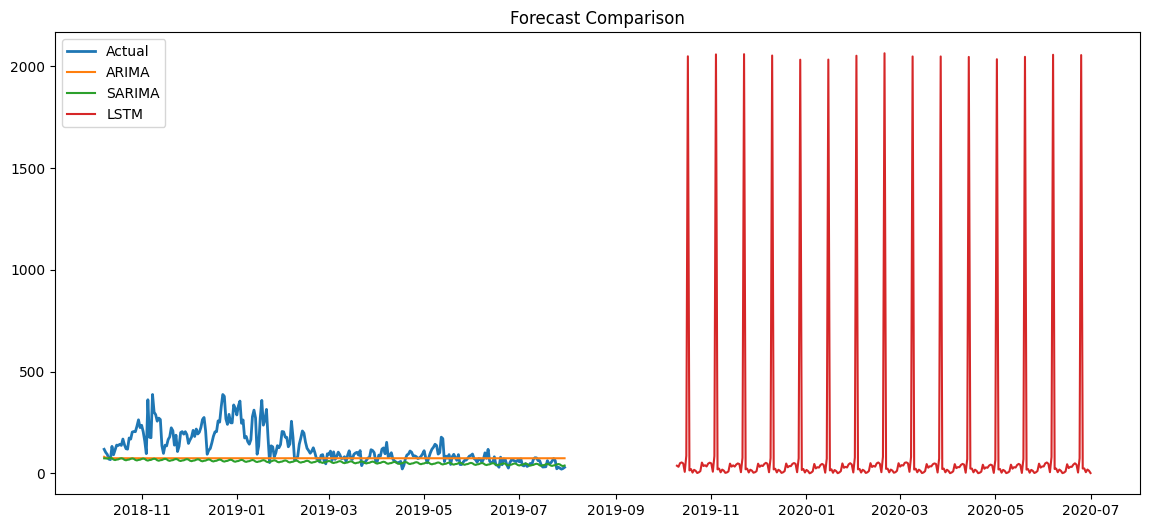

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test_arima, label="Actual", linewidth=2)
plt.plot(arima_pred, label="ARIMA")
plt.plot(sarima_pred, label="SARIMA")
plt.plot(lstm_pred, label="LSTM")

plt.legend()
plt.title("Forecast Comparison")
plt.show()

#### 4.8 STABILITY CHECK

In [52]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

errors = []
window = 200

series = series.asfreq("D")

for i in range(window, window + 200):
    train_slice = series.iloc[:i]

    model = ARIMA(train_slice, order=(2,1,2)).fit()
    pred = model.forecast(steps=1).iloc[0]

    actual = series.iloc[i]

    errors.append(abs(actual - pred))

print("Rolling MAE:", np.mean(errors))
print("Std:", np.std(errors))

Rolling MAE: 29.502367940380218
Std: 30.37929879169473


# 5. Evaluation

#### 5.1 METRICS (MAE, RMSE, MAPE, sMAPE)

In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def evaluate_all(y_true, y_pred):
    # align indices safely
    y_true, y_pred = y_true.align(y_pred, join="inner")
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape_val = smape(y_true.values, y_pred.values)
    
    return mae, rmse, mape, smape_val

results = {}

results["Naive"] = evaluate_all(y_test_naive, naive_pred)
results["MovingAvg"] = evaluate_all(y_test_ma, ma_pred)
results["ARIMA"] = evaluate_all(y_test_arima, arima_pred)
results["SARIMA"] = evaluate_all(y_test_arima, sarima_pred)
results["LSTM"] = evaluate_all(y_test_lstm, lstm_pred)

results_df = pd.DataFrame(results, index=["MAE","RMSE","MAPE","sMAPE"]).T
display(results_df.sort_values("RMSE"))

,MAE,RMSE,MAPE,sMAPE
LSTM,13.741675,18.309959,inf,77.359039
Naive,11.836134,29.666210,inf,29.740708
MovingAvg,16.319353,36.370686,inf,44.991955
ARIMA,65.346350,95.977237,46.164712,52.929084
SARIMA,73.395758,103.505159,46.537807,64.071047


#### 5.2 SHORT-TERM vs LONG-TERM PERFORMANCE

In [55]:
def split_horizon(y_true, y_pred, split=0.3):
    y_true, y_pred = y_true.align(y_pred, join="inner")
    
    n = len(y_true)
    split_point = int(n * split)
    
    short_true = y_true[:split_point]
    short_pred = y_pred[:split_point]
    
    long_true = y_true[split_point:]
    long_pred = y_pred[split_point:]
    
    return short_true, short_pred, long_true, long_pred

comparison = {}

for name, (y_true, y_pred) in {
    "ARIMA": (y_test_arima, arima_pred),
    "SARIMA": (y_test_arima, sarima_pred),
    "LSTM": (y_test_lstm, lstm_pred)
}.items():
    
    st_true, st_pred, lt_true, lt_pred = split_horizon(y_true, y_pred)
    
    st_mae = mean_absolute_error(st_true, st_pred)
    lt_mae = mean_absolute_error(lt_true, lt_pred)
    
    comparison[name] = [st_mae, lt_mae]

horizon_df = pd.DataFrame(comparison, index=["Short-term MAE", "Long-term MAE"]).T
display(horizon_df)

,Short-term MAE,Long-term MAE
ARIMA,126.568629,39.444616
SARIMA,134.800477,47.416839
LSTM,15.405828,13.038638


#### 5.3 SHORT vs LONG VISUAL

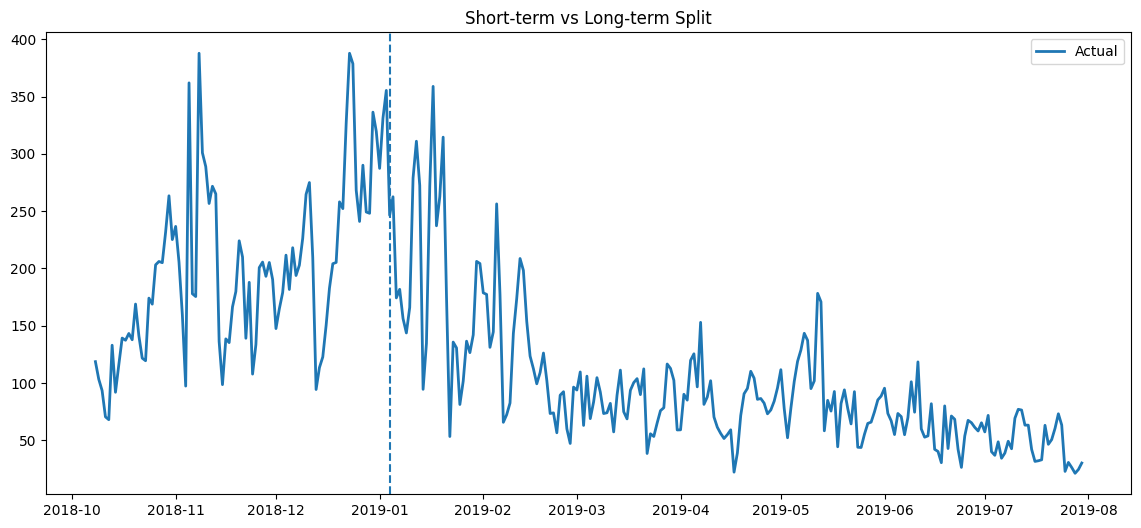

In [56]:
plt.figure(figsize=(14,6))

split = int(len(y_test_arima) * 0.3)

plt.plot(y_test_arima, label="Actual", linewidth=2)

plt.axvline(y_test_arima.index[split], linestyle='--')

plt.title("Short-term vs Long-term Split")
plt.legend()
plt.show()

#### 5.4 ERROR COMPARISON BAR PLOT

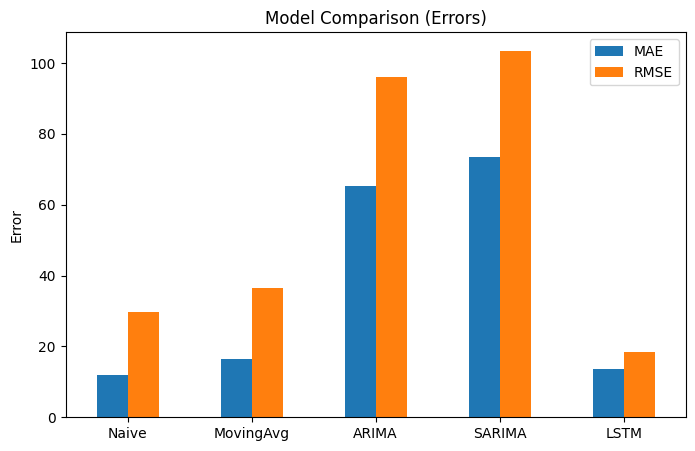

In [57]:
results_df[["MAE","RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison (Errors)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

#### 5.5 RESIDUAL ANALYSIS (MODEL BEHAVIOR)

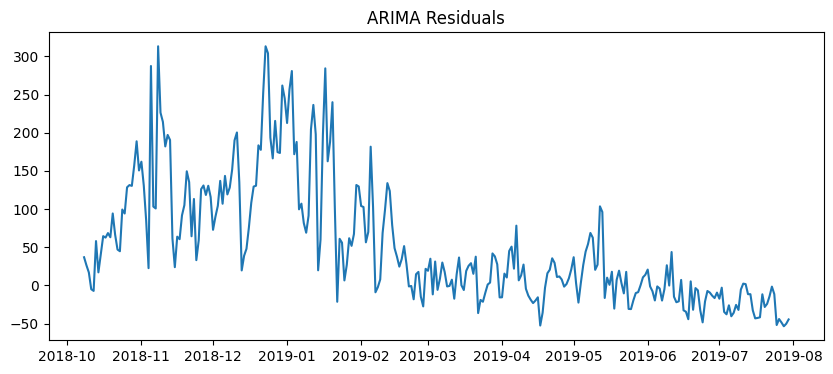

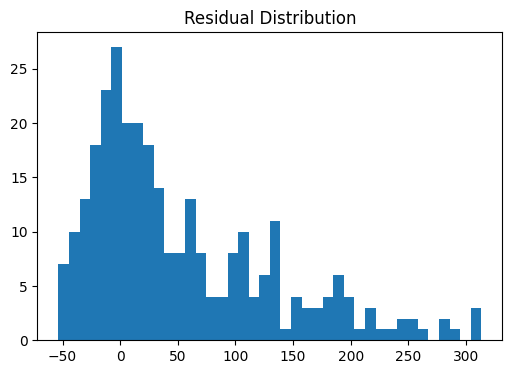

In [59]:
residuals_arima = y_test_arima - arima_pred

plt.figure(figsize=(10,4))
plt.plot(residuals_arima)
plt.title("ARIMA Residuals")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals_arima, bins=40)
plt.title("Residual Distribution")
plt.show()

#### 5.6 STABILITY SUMMARY 

In [60]:
print("Rolling MAE:", np.mean(errors))
print("Error Variance:", np.var(errors))

Rolling MAE: 29.502367940380218
Error Variance: 922.9017950750649


#### 5.7 FINAL COMPARISON TABLE

In [61]:
final_df = results_df.copy()
final_df["Stability (Std Error)"] = np.std(errors)

display(final_df.sort_values("RMSE"))

,MAE,RMSE,MAPE,sMAPE,Stability (Std Error)
LSTM,13.741675,18.309959,inf,77.359039,30.379299
Naive,11.836134,29.666210,inf,29.740708,30.379299
MovingAvg,16.319353,36.370686,inf,44.991955,30.379299
ARIMA,65.346350,95.977237,46.164712,52.929084,30.379299
SARIMA,73.395758,103.505159,46.537807,64.071047,30.379299


-------------------------------------------------------